# Pricing company equity and debt using option pricing under Merton model

### Stock price data

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
AAPL_data = pd.read_csv("../../data/AAPL_stock_price.csv", skiprows=[0,1,2], names=["Date", "Adj Close", "Close", "High", "Low", "Open", "Volume"])
AAPL_data.tail()


,Date,Adj Close,Close,High,Low,Open,Volume
0,2025-12-30,272.824707,273.079987,274.079987,272.279999,272.809998,22139600


### Risk-free rate data

In [6]:
US_treasury_yield3m = pd.read_csv("../../data/US_treasury_yield3m.csv", skiprows=[0], names=["Date", "US_treasury_yield3m"])

# select the 2025-12-31 data
US_treasury_yield3m_20251231 = US_treasury_yield3m[US_treasury_yield3m['Date'] == '2025-12-31']
print(US_treasury_yield3m_20251231)
print(US_treasury_yield3m_20251231.iloc[0])


             Date  US_treasury_yield3m
11566  2025-12-31                 3.67
Date                   2025-12-31
US_treasury_yield3m          3.67
Name: 11566, dtype: object


### Balance sheet data

In [7]:
import yfinance as yf

# Download Coca-Cola data
ko = yf.Ticker("KO")

# Get balance sheet (includes assets)
ko_balance_sheet = ko.balance_sheet
ko_balance_sheet.to_csv("../../data/ko_balance_sheet.csv", index_label="Date")
# print(ko_balance_sheet) # Access specific row

# # Download JP Morgan data
# jpm = yf.Ticker("JPM")

# # Get balance sheet (includes assets)
# jpm_balance_sheet = jpm.balance_sheet
# jpm_balance_sheet.to_csv("../../data/jpm_balance_sheet.csv", index_label="Date")
# print(jpm_balance_sheet) # Access specific row


In [8]:
# download the share outstanding data from yahoo finance for coca-cola
ko_balance_sheet = pd.read_csv("../../data/ko_balance_sheet.csv")
ordinary_shares_outstanding = ko_balance_sheet.iloc[1, :] # select the row of 'Ordinary Shares Outstanding'
print(ordinary_shares_outstanding.iloc[1])

# data = yf.download("ko", start="2025-12-31", end="2026-01-01", interval="1d", auto_adjust=False, progress=False) # 2025 last day of stock price data
# data.to_csv("../../data/ko_stock_price.csv", index_label="Date")
ko_stock_price = pd.read_csv("../../data/ko_stock_price.csv", skiprows=[0,1,2], names=["Date", "Adj Close", "Close", "High", "Low", "Open", "Volume"])
adj_close = ko_stock_price.iloc[:, 1]
print(adj_close[0])

# print(f"The market cap of Coca-Cola is {ordinary_shares_outstanding * adj_close :.2f}.")
print(f"The market cap of Coca-Cola is {ordinary_shares_outstanding.iloc[1] * adj_close[0] :.2f}.")

ko_total_debt = ko_balance_sheet.iloc[4, 1] # select the row of 'Total Debt'
print(f"The total debt of Coca-Cola is {ko_total_debt :.2f}.")

4301608845.0
69.59149169921875
The market cap of Coca-Cola is 299355376230.10.
The total debt of Coca-Cola is 45492000000.00.


### calculate the realized volatility of Coca-Cola stock price and the implied volatility of Coca-Cola stock price

define $\sigma_{\text{real}} = \sqrt{\frac{1}{252}\sum_{i=1}^{252} (log(S_{t_{i+1}}) - log(S_{t_i}))^2}$

Given GBM log returns: $ r_i=\log\frac{S_{t_{i+1}}}{S_{t_i}} \sim N(0,\sigma^2\Delta t),\quad \Delta t=\frac{1}{252} $ then $ \frac{r_i}{\sigma\sqrt{\Delta t}} \sim N(0,1),\quad \frac{r_i^2}{\sigma^2\Delta t}\sim \chi^2_1. $

So with (n) daily returns (about 252): $ \sum_{i=1}^n r_i^2 \approx \sigma^2 \Delta t ,\chi^2_n. $

A standard annualized realized-vol estimator is: $ \hat{\sigma_RV}=\sqrt{\frac{1}{\Delta t}\sum_{i=1}^n r_i^2} = \sqrt{252\sum_{i=1}^n r_i^2}. $

Or using sample std: $ \hat{\sigma}_{RV}=\operatorname{std}(r_i)\sqrt{252}. $


In [9]:
import numpy as np

# calculate the realized volatility of Coca-Cola stock price
ko = yf.Ticker("KO")
# Fetch daily price history for 2025
df = ko.history(start="2025-01-01", end="2025-12-31")
df['log_ret'] = np.log(df['Close'] / df['Close'].shift(1))
daily_vol = df['log_ret'].dropna().std(ddof=1)
realized_vol = daily_vol * np.sqrt(252)
print(f"KO Realized Volatility in 2025: {realized_vol:.2%}")

# calculate the implied volatility of Coca-Cola stock price
from IV import implied_volatility

iv_call, iv_put, iv_atm, call_strike, put_strike, spot, expiry = implied_volatility("KO")
print(f"Implied Volatility of Coca-Cola Call: {iv_call:.2%}")
print(f"Implied Volatility of Coca-Cola Put: {iv_put:.2%}")
print(f"Implied Volatility of Coca-Cola ATM: {iv_atm:.2%}")
print(f"Call Strike: {call_strike:.2f}")
print(f"Put Strike: {put_strike:.2f}")
print(f"Spot: {spot:.2f}")
print(f"Expiry: {expiry}")


KO Realized Volatility in 2025: 17.52%
Implied Volatility of Coca-Cola Call: 64.45%
Implied Volatility of Coca-Cola Put: 46.09%
Implied Volatility of Coca-Cola ATM: 55.27%
Call Strike: 69.00
Put Strike: 69.00
Spot: 69.43
Expiry: 2026-05-01


In [10]:
from bs_pricing import black_scholes_call, black_scholes_put
import math

us_treasury_yield3m = pd.read_csv("../../data/US_treasury_yield3m.csv", skiprows=[0], names=["Date", "US_treasury_yield3m"])

S = ordinary_shares_outstanding.iloc[1] * adj_close[0]+ ko_total_debt # market price of assets = market cap + total debt
K = ko_total_debt
T = 1 # 1 year
r = US_treasury_yield3m_20251231.iloc[0].values[1] / 100
sigma = iv_atm

print(f"The merton model price of Coca-Cola equity in 1 year is {black_scholes_call(S, K, T, r, sigma) :.2f}.")
print(f"The merton model price of Coca-Cola debt in 1 year is {K * math.exp(-r * T) - black_scholes_put(S, K, T, r, sigma) :.2f}.")

T = 3
print(f"The merton model price of Coca-Cola equity in 3 year is {black_scholes_call(S, K, T, r, sigma) :.2f}.")
print(f"The merton model price of Coca-Cola debt in 3 year is {K * math.exp(-r * T) - black_scholes_put(S, K, T, r, sigma) :.2f}.")

T = 5
print(f"The merton model price of Coca-Cola equity in 5 year is {black_scholes_call(S, K, T, r, sigma) :.2f}.")
print(f"The merton model price of Coca-Cola debt in 5 year is {K * math.exp(-r * T) - black_scholes_put(S, K, T, r, sigma) :.2f}.")

The merton model price of Coca-Cola equity in 1 year is 300996163494.63.
The merton model price of Coca-Cola debt in 1 year is 43851212735.47.
The merton model price of Coca-Cola equity in 3 year is 304561203613.86.
The merton model price of Coca-Cola debt in 3 year is 40286172616.24.
The merton model price of Coca-Cola equity in 5 year is 308782565678.60.
The merton model price of Coca-Cola debt in 5 year is 36064810551.50.


### Extend Merton pricing to multiple companies

The table below stores one row per ticker with columns ordered as:
- Equity: 1Y, 3Y, 5Y
- Debt: 1Y, 3Y, 5Y

In [11]:
import os
import math
import numpy as np
import pandas as pd
import yfinance as yf
from IV import implied_volatility
from bs_pricing import black_scholes_call, black_scholes_put

# Requested tickers to extend from the original notebook
TICKERS = ["AAPL", "JPM", "XOM", "T", "F", "UAL", "AMZN", "KO"]
MATURITIES = [1, 3, 5]

# Use the same risk-free rate date convention as above (2025-12-31, 3M yield)
us_treasury_yield3m = pd.read_csv("../../data/US_treasury_yield3m.csv", skiprows=[0], names=["Date", "US_treasury_yield3m"])
r = (
    us_treasury_yield3m.loc[
        us_treasury_yield3m["Date"] == "2025-12-31", "US_treasury_yield3m"
    ].iloc[0]
    / 100
)


def _load_local_spot_price(ticker: str) -> float:
    """Read 2025-12-31-ish adjusted close from local CSV if available."""
    candidates = [
        f"../../data/{ticker}_stock_price.csv",
        f"../../data/{ticker.lower()}_stock_price.csv",
    ]

    for path in candidates:
        if os.path.exists(path):
            stock_df = pd.read_csv(
                path,
                skiprows=[0, 1, 2],
                names=["Date", "Adj Close", "Close", "High", "Low", "Open", "Volume"],
            )
            return float(stock_df.iloc[0]["Adj Close"])

    # Fallback: download the last trading day in 2025 from yfinance
    hist = yf.download(ticker, start="2025-12-30", end="2026-01-03", interval="1d", auto_adjust=False, progress=False)
    return float(hist["Adj Close"].dropna().iloc[-1])


def _latest_balance_sheet_values(ticker: str) -> tuple[float, float]:
    """Return (shares_outstanding, total_debt) from latest balance sheet snapshot."""
    bs = yf.Ticker(ticker).balance_sheet
    latest_col = bs.columns[0]

    shares_candidates = ["Ordinary Shares Number", "Share Issued", "Ordinary Shares Outstanding"]
    debt_candidates = ["Total Debt", "Total Liabilities Net Minority Interest"]

    shares_outstanding = np.nan
    total_debt = np.nan

    for row_name in shares_candidates:
        if row_name in bs.index:
            shares_outstanding = bs.loc[row_name, latest_col]
            break

    for row_name in debt_candidates:
        if row_name in bs.index:
            total_debt = bs.loc[row_name, latest_col]
            break

    if pd.isna(shares_outstanding):
        shares_outstanding = yf.Ticker(ticker).info.get("sharesOutstanding", np.nan)

    if pd.isna(shares_outstanding) or pd.isna(total_debt):
        raise ValueError(f"Could not retrieve shares/debt for {ticker} from balance sheet.")

    return float(shares_outstanding), float(total_debt)


records = []

for ticker in TICKERS:
    try:
        iv_call, iv_put, iv_atm, *_ = implied_volatility(ticker)
        sigma = float(iv_atm)

        shares_outstanding, total_debt = _latest_balance_sheet_values(ticker)
        spot = _load_local_spot_price(ticker)

        # Merton setup: asset value = equity market cap + debt face value
        S = shares_outstanding * spot + total_debt
        K = total_debt

        row = {"ticker": ticker}
        for T in MATURITIES:
            equity_price = black_scholes_call(S, K, T, r, sigma)
            debt_price = K * math.exp(-r * T) - black_scholes_put(S, K, T, r, sigma)

            row[f"equity_price_{T}y"] = equity_price
            row[f"debt_price_{T}y"] = debt_price

        records.append(row)

    except Exception as exc:
        print(f"Skipping {ticker} due to error: {exc}")


merton_prices = pd.DataFrame(records)

# Ordered exactly as requested: ticker, equity 1y/3y/5y, debt 1y/3y/5y
ordered_cols = [
    "ticker",
    "equity_price_1y",
    "equity_price_3y",
    "equity_price_5y",
    "debt_price_1y",
    "debt_price_3y",
    "debt_price_5y",
]
merton_prices = merton_prices[ordered_cols]

# Optional true long-format version (ticker, type, maturity, price)
merton_prices_long = merton_prices.melt(
    id_vars="ticker", var_name="metric", value_name="price"
)

merton_prices

,ticker,equity_price_1y,equity_price_3y,equity_price_5y,debt_price_1y,debt_price_3y,debt_price_5y
0,AAPL,4.034065e+12,4.040796e+12,4.047050e+12,9.510192e+10,8.837147e+10,8.211734e+10
1,JPM,8.817572e+11,9.196463e+11,9.586866e+11,4.819174e+11,4.440283e+11,4.049880e+11
2,XOM,5.039964e+11,5.113948e+11,5.197541e+11,4.180998e+10,3.441155e+10,2.605231e+10
3,T,1.780093e+11,1.978498e+11,2.151651e+11,1.478234e+11,1.279828e+11,1.106675e+11
4,F,7.969485e+10,1.125763e+11,1.337019e+11,1.382501e+11,1.053686e+11,8.424310e+10
5,UAL,4.224412e+10,5.159590e+10,5.686639e+10,2.486533e+10,1.551355e+10,1.024306e+10
6,AMZN,2.502233e+12,2.538712e+12,2.574537e+12,1.460335e+11,1.095540e+11,7.372931e+10
7,KO,3.009963e+11,3.045792e+11,3.088329e+11,4.385108e+10,4.026817e+10,3.601449e+10


# Heston model 

In [12]:
from Heston_EulerAndMilstein import MertonPricesUnderHestonMC

### Merton prices under Heston asset dynamics

Use Monte Carlo under Heston dynamics for firm asset value $A_t$ and price:
- Equity: $E_0 = e^{-rT}\mathbb{E}[(A_T - D)^+]$
- Debt: $B_0 = e^{-rT}\mathbb{E}[\min(A_T, D)]$

In [13]:
# Reuse inputs already constructed above
# S: asset value proxy = market cap + debt
# K: debt face value
# r: risk-free rate

MATURITIES = [1, 3, 5]

# Heston parameters 
heston_params = {
    "NoOfPaths": 30000,
    "NoOfSteps": 252,
    "v0": float(iv_atm**2),   # initialize variance from ATM implied vol
    "kappa": 2.0,             # mean reversion speed
    "theta": float(iv_atm**2),# long-run variance
    "xi": 0.35,               # vol-of-vol
    "rho": -0.7,              # leverage effect
}

heston_results = []
for T in MATURITIES:
    out = MertonPricesUnderHestonMC(
        asset_value=float(S),
        debt_face_value=float(K),
        T=float(T),
        r=float(r),
        seed=123 + T,
        **heston_params,
    )
    heston_results.append(
        {
            "maturity_year": T,
            "equity_price_heston": out["equity"],
            "debt_price_heston": out["debt"],
        }
    )

merton_heston_prices = pd.DataFrame(heston_results)
merton_heston_prices

,maturity_year,equity_price_heston,debt_price_heston
0,1,3.015778e+11,4.382732e+10
1,3,3.055956e+11,3.991034e+10
2,5,3.105560e+11,3.557898e+10


In [14]:
# Optional: extend Heston-Merton pricing to the same ticker set

heston_records = []
for ticker in TICKERS:
    try:
        iv_call, iv_put, iv_atm_t, *_ = implied_volatility(ticker)
        sigma_t = float(iv_atm_t)

        shares_outstanding, total_debt = _latest_balance_sheet_values(ticker)
        spot_t = _load_local_spot_price(ticker)

        asset_value_t = shares_outstanding * spot_t + total_debt
        debt_face_t = total_debt

        row = {"ticker": ticker}
        for T in MATURITIES:
            out = MertonPricesUnderHestonMC(
                asset_value=float(asset_value_t),
                debt_face_value=float(debt_face_t),
                T=float(T),
                r=float(r),
                NoOfPaths=20000,
                NoOfSteps=252,
                v0=float(sigma_t**2),
                kappa=2.0,
                theta=float(sigma_t**2),
                xi=0.35,
                rho=-0.7,
                seed=321 + T,
            )
            row[f"equity_price_heston_{T}y"] = out["equity"]
            row[f"debt_price_heston_{T}y"] = out["debt"]

        heston_records.append(row)

    except Exception as exc:
        print(f"Skipping {ticker} due to error: {exc}")

merton_heston_prices_all = pd.DataFrame(heston_records)

ordered_cols_heston = [
    "ticker",
    "equity_price_heston_1y",
    "equity_price_heston_3y",
    "equity_price_heston_5y",
    "debt_price_heston_1y",
    "debt_price_heston_3y",
    "debt_price_heston_5y",
]
merton_heston_prices_all = merton_heston_prices_all[ordered_cols_heston]
merton_heston_prices_all

,ticker,equity_price_heston_1y,equity_price_heston_3y,equity_price_heston_5y,debt_price_heston_1y,debt_price_heston_3y,debt_price_heston_5y
0,AAPL,4.035317e+12,4.033609e+12,4.050330e+12,9.510192e+10,8.837147e+10,8.211734e+10
1,JPM,8.811845e+11,9.226662e+11,9.682637e+11,4.814210e+11,4.395418e+11,3.998717e+11
2,XOM,5.017182e+11,5.347769e+11,5.231351e+11,4.169528e+10,3.395162e+10,2.586265e+10
3,T,1.786167e+11,2.002143e+11,2.187660e+11,1.466641e+11,1.259388e+11,1.090352e+11
4,F,7.910706e+10,1.133075e+11,1.347222e+11,1.382368e+11,1.059971e+11,8.531326e+10
5,UAL,4.204016e+10,5.511637e+10,5.675232e+10,2.477474e+10,1.554475e+10,1.038489e+10
6,AMZN,2.492481e+12,2.775203e+12,2.508645e+12,1.455051e+11,1.090898e+11,7.414739e+10
7,KO,3.001637e+11,3.065641e+11,3.125117e+11,4.383428e+10,3.978524e+10,3.530831e+10


In [15]:
# 1) Merge BS and Heston results on ticker
compare = merton_prices.merge(merton_heston_prices_all, on="ticker", how="inner")

# 2) Build comparison metrics for each maturity
for T in [1, 3, 5]:
    # Equity
    bs_eq = f"equity_price_{T}y"
    hes_eq = f"equity_price_heston_{T}y"
    compare[f"equity_diff_{T}y"] = compare[hes_eq] - compare[bs_eq]
    compare[f"equity_pct_diff_{T}y"] = compare[f"equity_diff_{T}y"] / compare[bs_eq] * 100

    # Debt
    bs_debt = f"debt_price_{T}y"
    hes_debt = f"debt_price_heston_{T}y"
    compare[f"debt_diff_{T}y"] = compare[hes_debt] - compare[bs_debt]
    compare[f"debt_pct_diff_{T}y"] = compare[f"debt_diff_{T}y"] / compare[bs_debt] * 100

# 3) Display compact view
cols = ["ticker"]
for T in [1, 3, 5]:
    cols += [
        f"equity_price_{T}y", f"equity_price_heston_{T}y", f"equity_pct_diff_{T}y",
        f"debt_price_{T}y", f"debt_price_heston_{T}y", f"debt_pct_diff_{T}y"
    ]

compare[cols]

,ticker,equity_price_1y,equity_price_heston_1y,equity_pct_diff_1y,debt_price_1y,debt_price_heston_1y,debt_pct_diff_1y,equity_price_3y,equity_price_heston_3y,equity_pct_diff_3y,debt_price_3y,debt_price_heston_3y,debt_pct_diff_3y,equity_price_5y,equity_price_heston_5y,equity_pct_diff_5y,debt_price_5y,debt_price_heston_5y,debt_pct_diff_5y
0,AAPL,4.034065e+12,4.035317e+12,0.031031,9.510192e+10,9.510192e+10,0.000000,4.040796e+12,4.033609e+12,-0.177848,8.837147e+10,8.837147e+10,0.000000,4.047050e+12,4.050330e+12,0.081053,8.211734e+10,8.211734e+10,0.000000
1,JPM,8.817572e+11,8.811845e+11,-0.064953,4.819174e+11,4.814210e+11,-0.102999,9.196463e+11,9.226662e+11,0.328385,4.440283e+11,4.395418e+11,-1.010423,9.586866e+11,9.682637e+11,0.998989,4.049880e+11,3.998717e+11,-1.263326
2,XOM,5.039964e+11,5.017182e+11,-0.452022,4.180998e+10,4.169528e+10,-0.274357,5.113948e+11,5.347769e+11,4.572218,3.441155e+10,3.395162e+10,-1.336555,5.197541e+11,5.231351e+11,0.650504,2.605231e+10,2.586265e+10,-0.728010
3,T,1.780093e+11,1.786167e+11,0.341247,1.478234e+11,1.466641e+11,-0.784222,1.978498e+11,2.002143e+11,1.195056,1.279828e+11,1.259388e+11,-1.597091,2.151651e+11,2.187660e+11,1.673554,1.106675e+11,1.090352e+11,-1.474951
4,F,7.969485e+10,7.910706e+10,-0.737559,1.382501e+11,1.382368e+11,-0.009605,1.125763e+11,1.133075e+11,0.649530,1.053686e+11,1.059971e+11,0.596426,1.337019e+11,1.347222e+11,0.763132,8.424310e+10,8.531326e+10,1.270324
5,UAL,4.224412e+10,4.204016e+10,-0.482823,2.486533e+10,2.477474e+10,-0.364328,5.159590e+10,5.511637e+10,6.823157,1.551355e+10,1.554475e+10,0.201138,5.686639e+10,5.675232e+10,-0.200597,1.024306e+10,1.038489e+10,1.384615
6,AMZN,2.502233e+12,2.492481e+12,-0.389736,1.460335e+11,1.455051e+11,-0.361831,2.538712e+12,2.775203e+12,9.315389,1.095540e+11,1.090898e+11,-0.423728,2.574537e+12,2.508645e+12,-2.559388,7.372931e+10,7.414739e+10,0.567046
7,KO,3.009963e+11,3.001637e+11,-0.276618,4.385108e+10,4.383428e+10,-0.038299,3.045792e+11,3.065641e+11,0.651677,4.026817e+10,3.978524e+10,-1.199297,3.088329e+11,3.125117e+11,1.191189,3.601449e+10,3.530831e+10,-1.960814


### Merton jump pricing model

In [21]:
from merton_jump_pricing import merton_jump_pricing_call, merton_jump_pricing_put
from IV import implied_volatility
import math 
import pandas as pd

TICKERS = ["AAPL", "JPM", "XOM", "T", "F", "UAL", "AMZN", "KO"]

MATURITIES = [1, 3, 5]
us_treasury_yield3m = pd.read_csv("../../data/US_treasury_yield3m.csv", skiprows=[0], names=["Date", "US_treasury_yield3m"])
r = (
    us_treasury_yield3m.loc[
        us_treasury_yield3m["Date"] == "2025-12-31", "US_treasury_yield3m"
    ].iloc[0]
    / 100
)
Lambda = 0.5
muJ = 0.0
sigmaJ = 0.5
N = 100

records = []

for ticker in TICKERS:
    try:
        iv_call, iv_put, iv_atm, *_ = implied_volatility(ticker)
        sigma = float(iv_atm)

        shares_outstanding, total_debt = _latest_balance_sheet_values(ticker)
        spot = _load_local_spot_price(ticker)

        # Merton setup: asset value = equity market cap + debt face value
        S = shares_outstanding * spot + total_debt
        K = total_debt

        row = {"ticker": ticker}
        for T in MATURITIES:
            equity_price = merton_jump_pricing_call(S, K, T, r, sigma, Lambda, muJ, sigmaJ, N)
            debt_price = K * math.exp(-r * T) - merton_jump_pricing_put(S, K, T, r, sigma, Lambda, muJ, sigmaJ, N)

            row[f"equity_price_Jump_{T}y"] = equity_price
            row[f"debt_price_Jump_{T}y"] = debt_price

        records.append(row)

    except Exception as exc:
        print(f"Skipping {ticker} due to error: {exc}")


merton_jump_prices = pd.DataFrame(records)

# Ordered exactly as requested: ticker, equity 1y/3y/5y, debt 1y/3y/5y
ordered_cols = [
    "ticker",
    "equity_price_Jump_1y",
    "equity_price_Jump_3y",
    "equity_price_Jump_5y",
    "debt_price_Jump_1y",
    "debt_price_Jump_3y",
    "debt_price_Jump_5y",
]
merton_jump_prices = merton_jump_prices[ordered_cols]

# Optional true long-format version (ticker, type, maturity, price)
merton_jump_prices_long = merton_jump_prices.melt(
    id_vars="ticker", var_name="metric", value_name="price"
)

merton_jump_prices

,ticker,equity_price_Jump_1y,equity_price_Jump_3y,equity_price_Jump_5y,debt_price_Jump_1y,debt_price_Jump_3y,debt_price_Jump_5y
0,AAPL,4.034065e+12,4.040801e+12,4.047109e+12,9.510190e+10,8.836650e+10,8.205805e+10
1,JPM,8.850372e+11,9.390575e+11,9.939391e+11,4.786374e+11,4.246171e+11,3.697355e+11
2,XOM,5.046108e+11,5.162632e+11,5.264133e+11,4.119562e+10,2.954315e+10,1.939311e+10
3,T,1.825502e+11,2.118174e+11,2.339437e+11,1.432825e+11,1.140152e+11,9.188893e+10
4,F,8.506854e+10,1.219732e+11,1.445330e+11,1.328764e+11,9.597173e+10,7.341201e+10
5,UAL,4.365588e+10,5.375240e+10,5.896144e+10,2.345357e+10,1.335705e+10,8.148014e+09
6,AMZN,2.500795e+12,2.511461e+12,2.522443e+12,1.474718e+11,1.368052e+11,1.258236e+11
7,KO,3.010319e+11,3.053386e+11,3.106411e+11,4.381546e+10,3.950880e+10,3.420632e+10


# Plot the different pricing models result

In [ ]:
merton_prices
merton_heston_prices_all
merton_jump_prices

  ticker  equity_price_1y  equity_price_3y  equity_price_5y  debt_price_1y  \
0   AAPL     4.034065e+12     4.040796e+12     4.047050e+12   9.510192e+10   
1    JPM     8.817572e+11     9.196463e+11     9.586866e+11   4.819174e+11   
2    XOM     5.039964e+11     5.113948e+11     5.197541e+11   4.180998e+10   
3      T     1.780093e+11     1.978498e+11     2.151651e+11   1.478234e+11   
4      F     7.969485e+10     1.125763e+11     1.337019e+11   1.382501e+11   
5    UAL     4.224412e+10     5.159590e+10     5.686639e+10   2.486533e+10   
6   AMZN     2.502233e+12     2.538712e+12     2.574537e+12   1.460335e+11   
7     KO     3.009963e+11     3.045792e+11     3.088329e+11   4.385108e+10   

   debt_price_3y  debt_price_5y  
0   8.837147e+10   8.211734e+10  
1   4.440283e+11   4.049880e+11  
2   3.441155e+10   2.605231e+10  
3   1.279828e+11   1.106675e+11  
4   1.053686e+11   8.424310e+10  
5   1.551355e+10   1.024306e+10  
6   1.095540e+11   7.372931e+10  
7   4.026817e+10   3.6014

,ticker,equity_price_Jump_1y,equity_price_Jump_3y,equity_price_Jump_5y,debt_price_Jump_1y,debt_price_Jump_3y,debt_price_Jump_5y
0,AAPL,4.034065e+12,4.040801e+12,4.047109e+12,9.510190e+10,8.836650e+10,8.205805e+10
1,JPM,8.850372e+11,9.390575e+11,9.939391e+11,4.786374e+11,4.246171e+11,3.697355e+11
2,XOM,5.046108e+11,5.162632e+11,5.264133e+11,4.119562e+10,2.954315e+10,1.939311e+10
3,T,1.825502e+11,2.118174e+11,2.339437e+11,1.432825e+11,1.140152e+11,9.188893e+10
4,F,8.506854e+10,1.219732e+11,1.445330e+11,1.328764e+11,9.597173e+10,7.341201e+10
5,UAL,4.365588e+10,5.375240e+10,5.896144e+10,2.345357e+10,1.335705e+10,8.148014e+09
6,AMZN,2.500795e+12,2.511461e+12,2.522443e+12,1.474718e+11,1.368052e+11,1.258236e+11
7,KO,3.010319e+11,3.053386e+11,3.106411e+11,4.381546e+10,3.950880e+10,3.420632e+10


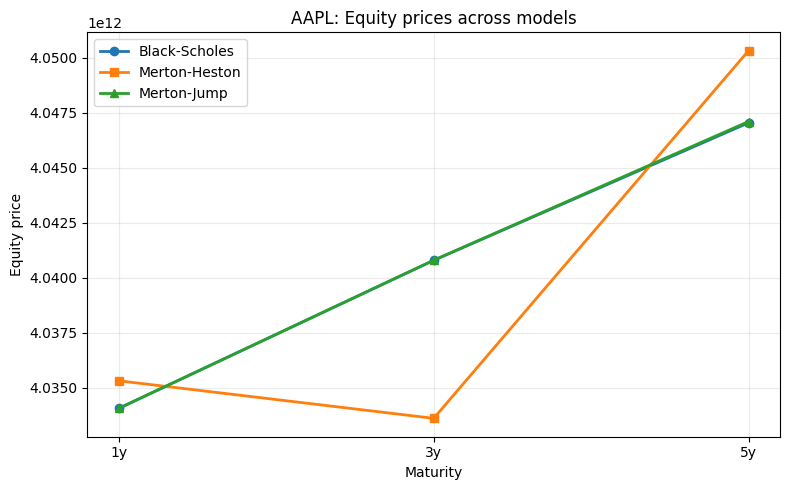

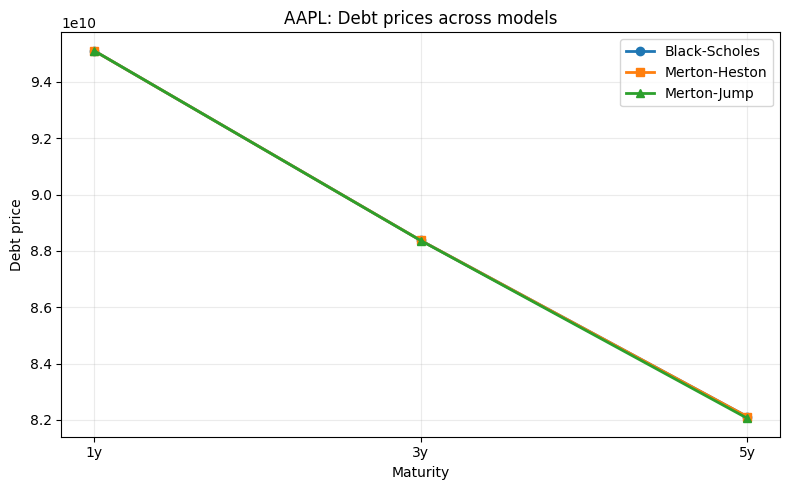

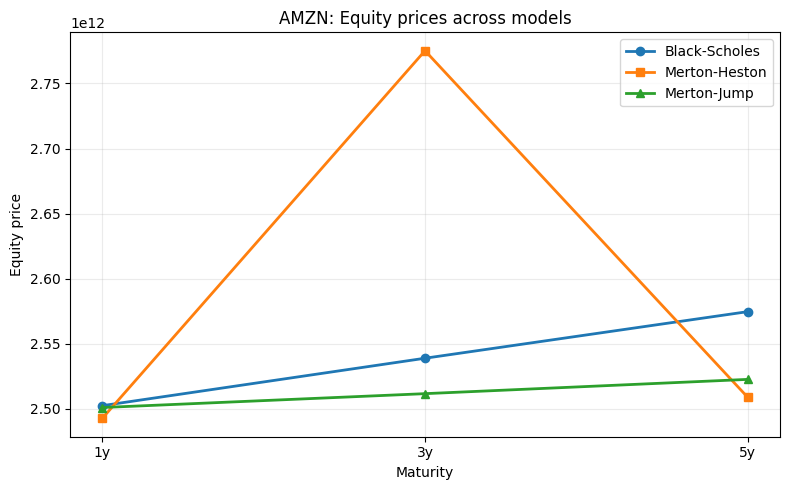

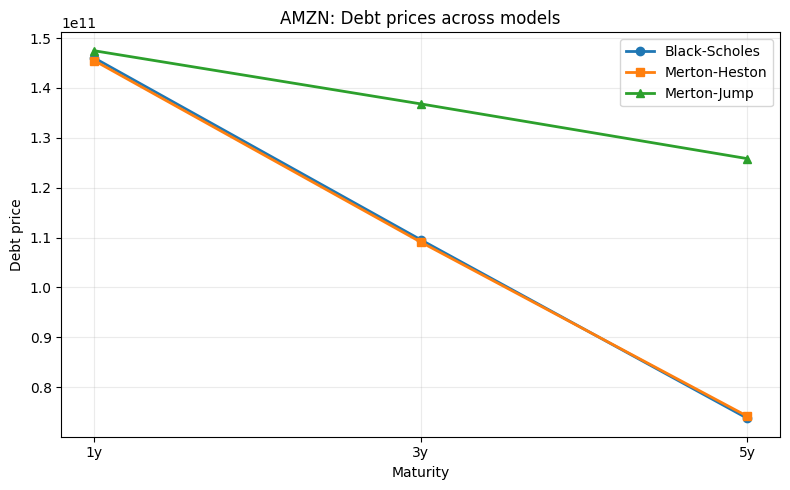

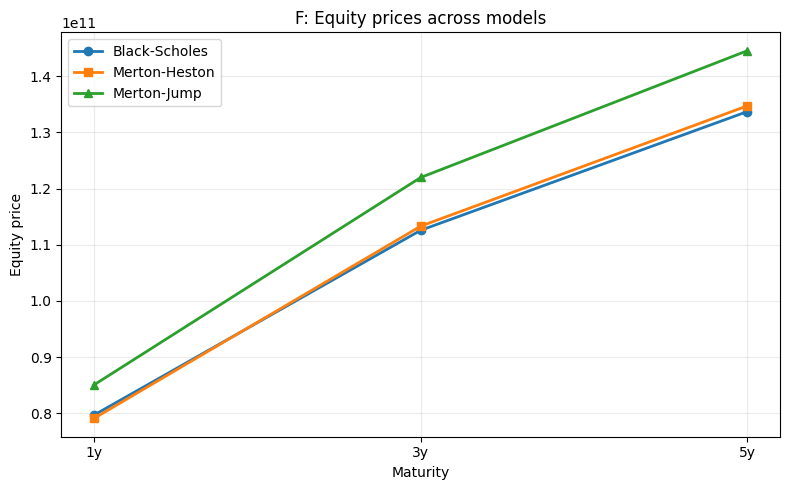

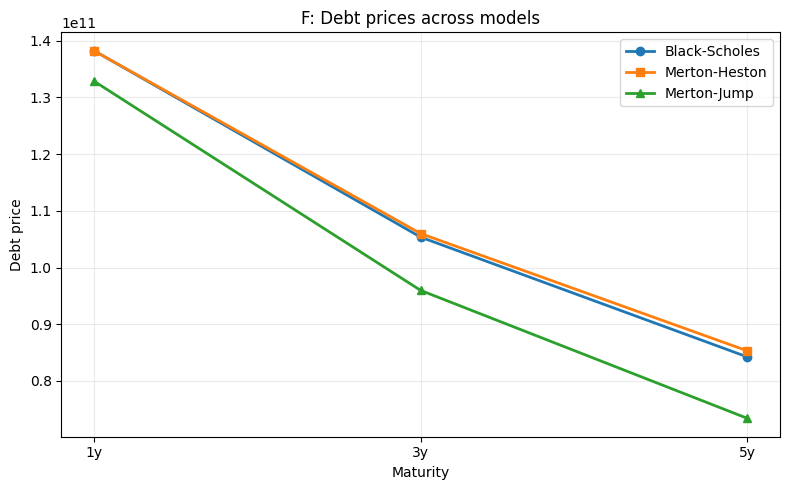

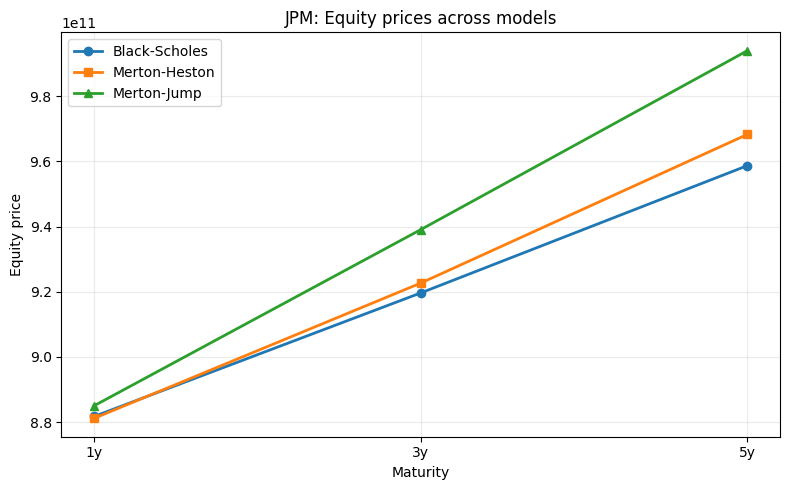

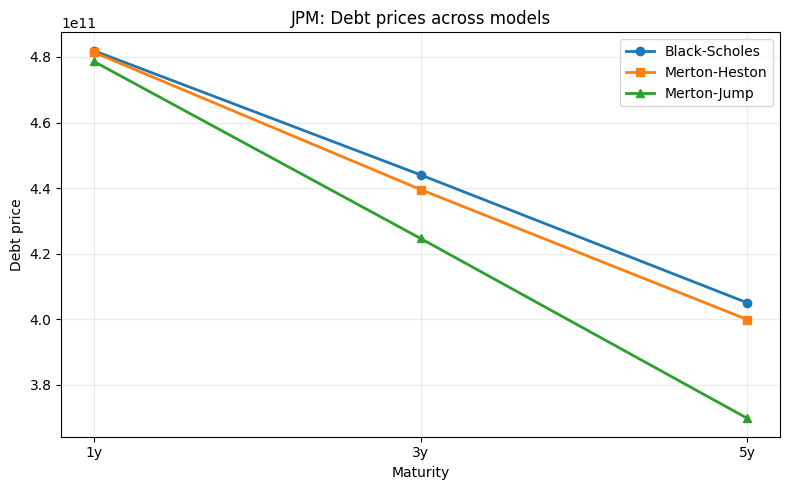

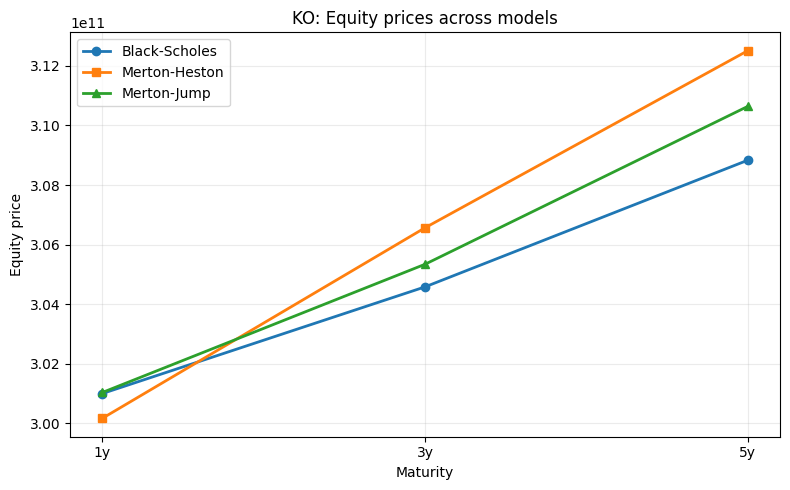

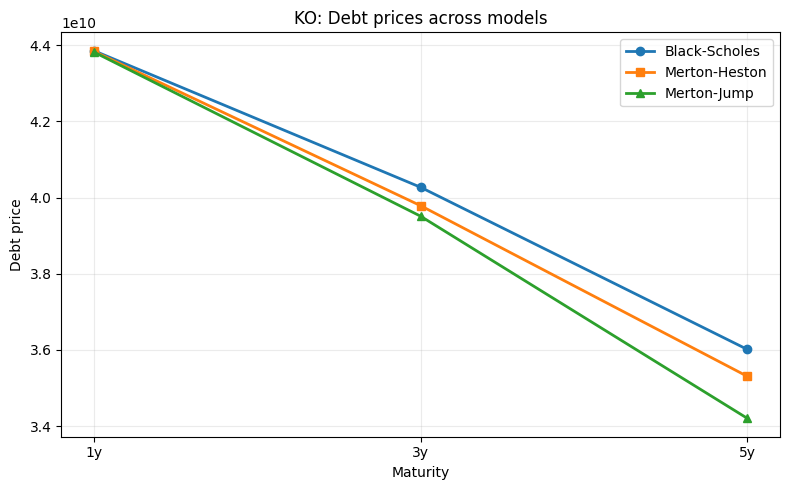

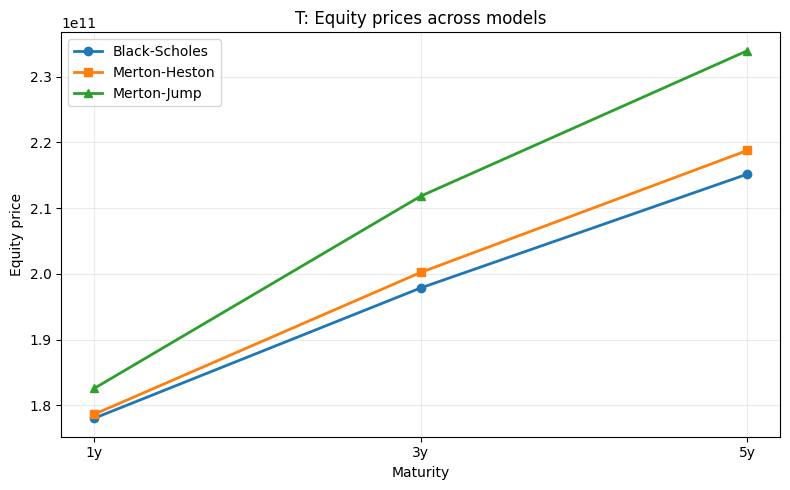

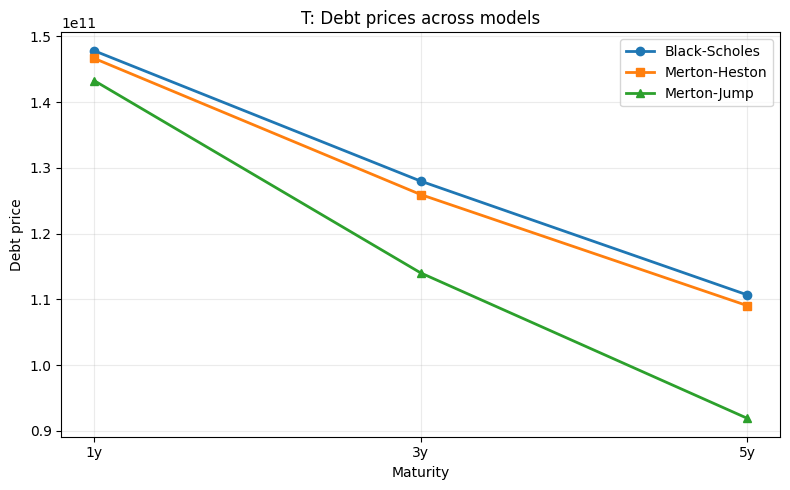

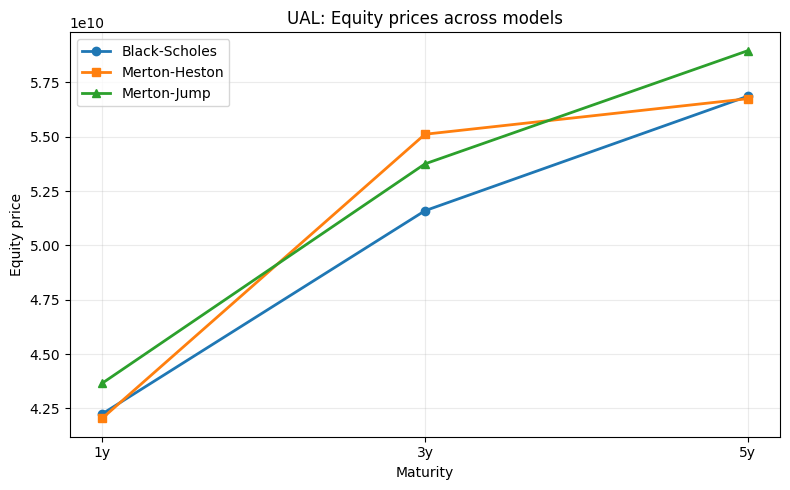

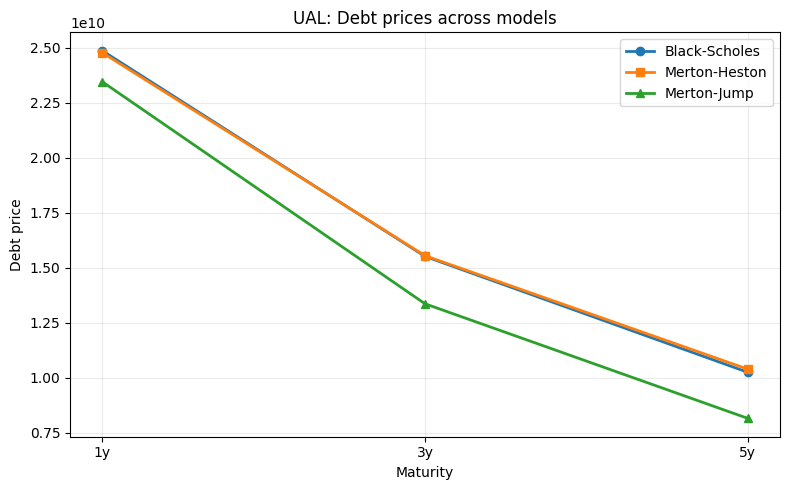

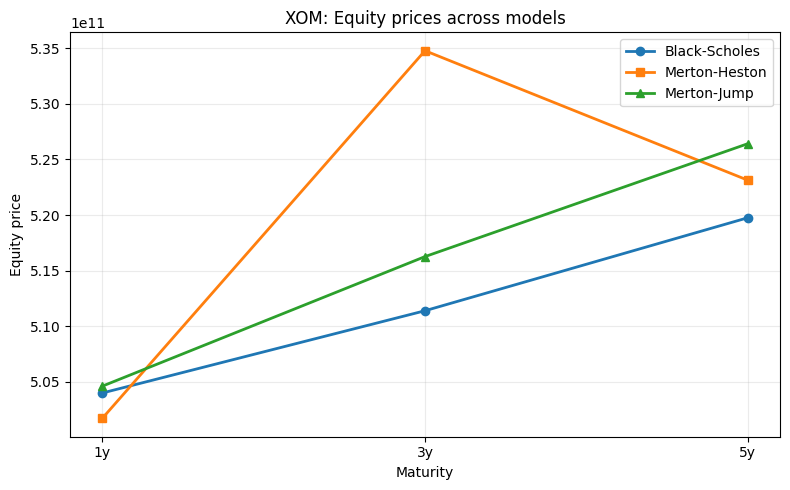

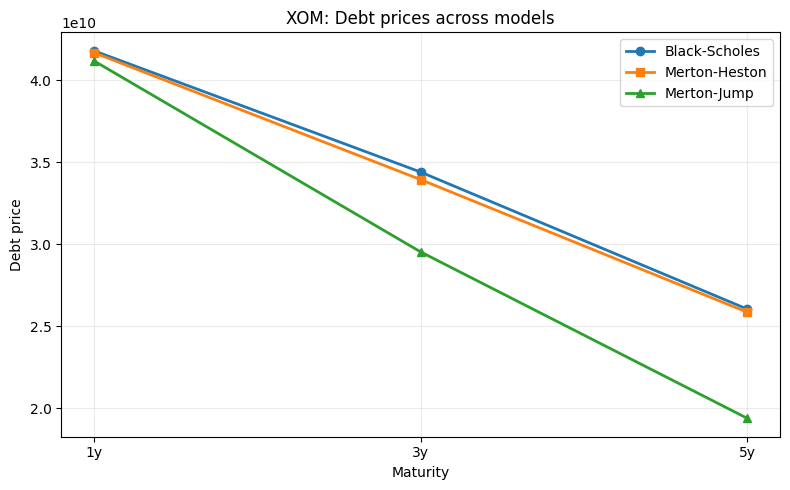

Generated 16 model-comparison plots (8 companies × 2).


In [24]:
import matplotlib.pyplot as plt

# Canonical column keys per series (equity vs debt); x-axis uses maturity labels
equity_x_cols = [
    "equity_price_Jump_1y",
    "equity_price_Jump_3y",
    "equity_price_Jump_5y",
]
debt_x_cols = [
    "debt_price_Jump_1y",
    "debt_price_Jump_3y",
    "debt_price_Jump_5y",
]
maturity_labels = ["1y", "3y", "5y"]

# Column mapping from each method dataframe -> canonical keys above
bs_map = {
    "equity_price_Jump_1y": "equity_price_1y",
    "equity_price_Jump_3y": "equity_price_3y",
    "equity_price_Jump_5y": "equity_price_5y",
    "debt_price_Jump_1y": "debt_price_1y",
    "debt_price_Jump_3y": "debt_price_3y",
    "debt_price_Jump_5y": "debt_price_5y",
}

heston_map = {
    "equity_price_Jump_1y": "equity_price_heston_1y",
    "equity_price_Jump_3y": "equity_price_heston_3y",
    "equity_price_Jump_5y": "equity_price_heston_5y",
    "debt_price_Jump_1y": "debt_price_heston_1y",
    "debt_price_Jump_3y": "debt_price_heston_3y",
    "debt_price_Jump_5y": "debt_price_heston_5y",
}

x_cols = equity_x_cols + debt_x_cols
jump_map = {col: col for col in x_cols}

common_tickers = sorted(
    set(merton_prices["ticker"]).intersection(
        merton_heston_prices_all["ticker"], merton_jump_prices["ticker"]
    )
)


def _plot_model_series(cols, bs_row, hes_row, jump_row, title, ylabel):
    bs_vals = [float(bs_row[bs_map[c]]) for c in cols]
    hes_vals = [float(hes_row[heston_map[c]]) for c in cols]
    jump_vals = [float(jump_row[jump_map[c]]) for c in cols]

    plt.figure(figsize=(8, 5))
    plt.plot(maturity_labels, bs_vals, marker="o", linewidth=2, label="Black-Scholes")
    plt.plot(maturity_labels, hes_vals, marker="s", linewidth=2, label="Merton-Heston")
    plt.plot(maturity_labels, jump_vals, marker="^", linewidth=2, label="Merton-Jump")
    plt.title(title)
    plt.xlabel("Maturity")
    plt.ylabel(ylabel)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()


for ticker in common_tickers:
    bs_row = merton_prices.loc[merton_prices["ticker"] == ticker].iloc[0]
    hes_row = merton_heston_prices_all.loc[merton_heston_prices_all["ticker"] == ticker].iloc[0]
    jump_row = merton_jump_prices.loc[merton_jump_prices["ticker"] == ticker].iloc[0]

    _plot_model_series(
        equity_x_cols,
        bs_row,
        hes_row,
        jump_row,
        title=f"{ticker}: Equity prices across models",
        ylabel="Equity price",
    )
    _plot_model_series(
        debt_x_cols,
        bs_row,
        hes_row,
        jump_row,
        title=f"{ticker}: Debt prices across models",
        ylabel="Debt price",
    )

print(f"Generated {2 * len(common_tickers)} model-comparison plots ({len(common_tickers)} companies × 2).")

heston:
calibrate the CIR